# CancerDetector

In [34]:
import sys
from pathlib import Path
import json

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.special import beta as beta_func

from methyldl.data.soft_labeling import extract_cpg_signature

In [2]:
label_dict = None
with open(ROOT /"App" / "labels_dict.json", "r") as f:
    label_dict = json.load(f)
cell_labels_to_names = {int(l): n for l, n in label_dict.items()}
cell_names_to_labels = {n: int(l) for l, n in label_dict.items()}
del label_dict

In [3]:
HARD_LABELS_PATH = ROOT / "Data" / "training_data" / "TrainingDataWithRejection_hg38_mincpg_4_minlen_10"
HARD_LABELS_PATH

PosixPath('/home/nathan/Documents/Scolaire/7_Cesure/2_KU_Leuven/methyldl/Data/training_data/TrainingDataWithRejection_hg38_mincpg_4_minlen_10')

In [4]:
train_data = pd.read_parquet(HARD_LABELS_PATH / "train.parquet")

In [5]:
train_data.head().T

,0,1,2,3,4
chr,chr1,chr1,chr1,chr1,chr1
read_name,12898846,12898843,12898848,12898845,12898850
trimmed_start,226254706,226254706,226254706,226254706,226254707
trimmed_end,226254803,226254827,226254835,226254848,226254835
pattern,0222222222222222222202222222222222222222222222...,1222222222222222222202222222222222222222222222...,0222222222222222222202222222222222222222222222...,0222222222222222222202222222222222222222222222...,2222222222222222222122222222222222222222222222...
seq,CGAGACCATCCTGGCTAACACGGTGAAACCCCATCTCTACTAAAAA...,CGAGACCATCCTGGCTAACACGGTGAAACCCCATCTCTACTAAAAA...,CGAGACCATCCTGGCTAACACGGTGAAACCCCATCTCTACTAAAAA...,CGAGACCATCCTGGCTAACACGGTGAAACCCCATCTCTACTAAAAA...,GAGACCATCCTGGCTAACACGGTGAAACCCCATCTCTACTAAAAAT...
name,chr1:226254707-226255135,chr1:226254707-226255135,chr1:226254707-226255135,chr1:226254707-226255135,chr1:226254707-226255135
region_start,226254706,226254706,226254706,226254706,226254706
region_end,226255135,226255135,226255135,226255135,226255135
original_label,0,0,0,0,0


In [6]:
train_data["label"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39])

In [7]:
train_data["original_label"].unique()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38])

In [8]:
dmr_label_cnts = train_data.groupby("dmr_label").agg(
    cnt=("dmr_label", "size"),
    dmr_ctype_label=("dmr_ctype_label", "first"),
).reset_index()
dmr_label_cnts["dmr_ctype_name"] = dmr_label_cnts["dmr_ctype_label"].map(cell_labels_to_names)
# cell_type_counts = dmr_label_cnts.groupby("cell_type_name").agg(
#     cnt=("cnt", "sum")).reset_index().sort_values("cnt", ascending=False)
# cell_type_counts
dmr_ctype_label_cnts = train_data.groupby("dmr_ctype_label").agg(
    cnt=("dmr_ctype_label", "size"),
).reset_index()
dmr_ctype_label_cnts["dmr_ctype_name"] = dmr_ctype_label_cnts["dmr_ctype_label"].map(cell_labels_to_names)
dmr_ctype_label_cnts

,dmr_ctype_label,cnt,dmr_ctype_name
0,0,2945,Thyroid-Ep
1,1,2505,Blood-Granul
2,2,4326,Heart-Cardio
3,3,2475,Lung-Ep-Alveo
4,4,5557,Kidney-Ep
5,5,6164,Neuron
6,6,6001,Liver-Hep
7,7,1921,Dermal-Fibro
8,8,3272,Bladder-Ep
9,9,10046,Blood-T


For every model, every class, we fit a beta distribution

In [9]:
beta_params_eta_matrix = np.ones((len(dmr_ctype_label_cnts), len(train_data["original_label"].unique())))
beta_params_rho_matrix = np.ones((len(dmr_ctype_label_cnts), len(train_data["original_label"].unique())))
beta_params_cnts_matrix = np.zeros((len(dmr_ctype_label_cnts), len(train_data["original_label"].unique())))

In [39]:
np.clip([-2,-1,0,1], 0, None)

array([0, 0, 0, 1])

In [40]:
np.array([0,1,2]).sum()

np.int64(3)

In [10]:
EPSILON = 0.01
for dmr_ctype_label in dmr_ctype_label_cnts["dmr_ctype_label"]:
    for ctype_label in train_data["original_label"].unique():
        subset = train_data.loc[
            (train_data["dmr_ctype_label"] == dmr_ctype_label) &
            (train_data["original_label"] == ctype_label)
        ]
        cnt = len(subset)
        beta_params_cnts_matrix[dmr_ctype_label, ctype_label] = cnt
        avg_meth_rates = subset["M_rate"].to_numpy()
        # clipping 0 and 1 values to avoid issues with beta fitting
        clipped_avg_meth_rates = np.clip(avg_meth_rates, EPSILON, 1 - EPSILON)
        if cnt < 3:
            continue # not enough data to fit a beta distribution

        try:
            # if all cpg sites are unmethylated, we use bayesian estimation with a uniform prior (alpha=1, beta=1) to avoid issues with beta fitting
            if np.all(avg_meth_rates == 0):
                n_cpgs = subset["NCPGS"].sum()
                eta = 1
                rho = n_cpgs + 1
            # if all cpg sites are fully methylated, we use bayesian estimation with a uniform prior (alpha=1, beta=1) to avoid issues with beta fitting
            elif np.all(avg_meth_rates == 1):
                n_cpgs = subset["NCPGS"].sum()
                eta = n_cpgs + 1
                rho = 1
            else: # fit a beta distribution to the average methylation rates
                eta, rho, _, _ = stats.beta.fit(clipped_avg_meth_rates, floc=0, fscale=1)
            beta_params_eta_matrix[dmr_ctype_label, ctype_label] = eta
            beta_params_rho_matrix[dmr_ctype_label, ctype_label] = rho
        except Exception as e:
            print(f"Error fitting beta distribution for dmr_ctype_label={dmr_ctype_label}, original_label={ctype_label}, clipped_avg_meth_rates={clipped_avg_meth_rates}: {e}")

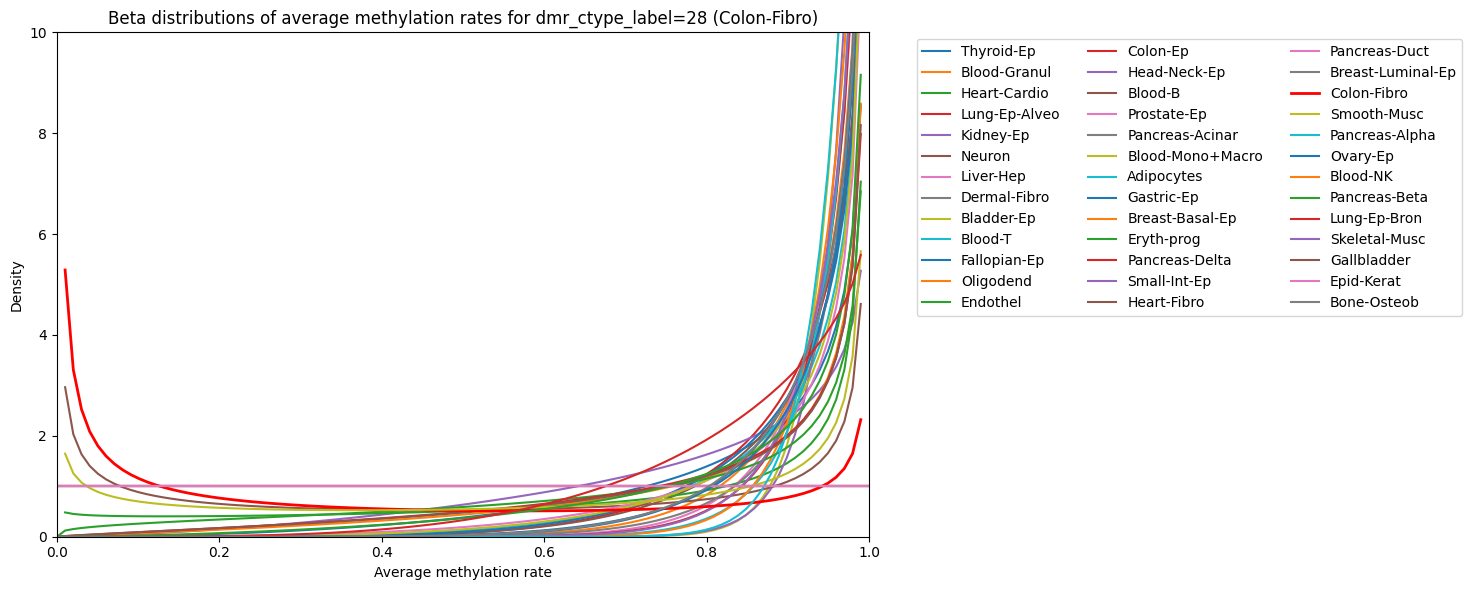

In [33]:
# 1 plot with the 39 curves of all the cell types for a given dmr_ctype_label
dmr_ctype_label = 28
x = np.linspace(0, 1, 100)
plt.figure(figsize=(15, 6))
for ctype_label in train_data["original_label"].unique():
    eta = beta_params_eta_matrix[dmr_ctype_label, ctype_label]
    rho = beta_params_rho_matrix[dmr_ctype_label, ctype_label]
    y = stats.beta.pdf(x, eta, rho)
    if ctype_label == dmr_ctype_label:
        plt.plot(x, y, label=cell_labels_to_names[ctype_label], color="red", linewidth=2)
    else:
        plt.plot(x, y, label=cell_labels_to_names[ctype_label])
plt.title(f"Beta distributions of average methylation rates for dmr_ctype_label={dmr_ctype_label} ({cell_labels_to_names[dmr_ctype_label]})")
plt.xlabel("Average methylation rate")
plt.ylabel("Density")
plt.xlim(0, 1)
plt.ylim(0, 10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
plt.tight_layout()
plt.show()

Now there are two methods to obtain a mixture proportion:
- marginalization: we can compute P(c|r) prop P(r|c)P(c) and then normalize across classes
- MLE: we can compute the likelihood of the observations given a mixture proportion and then optimize the mixture proportion to maximize the likelihood

In [35]:
# Now we define a function that takes as input a dmr_ctype_label and a number of methylated and unmethylated cpg sites
# and outputs a vector of likelihood of the read coming from each of the 39 cell types according to the beta distributions we fitted above
def compute_likelihood(dmr_ctype_label, n_meth_cpgs, n_unmeth_cpgs):
    n_cpgs = n_meth_cpgs + n_unmeth_cpgs
    if n_cpgs == 0:
        return np.ones(len(train_data["original_label"].unique())) / len(train_data["original_label"].unique()) # if there are no cpg sites, we return a uniform distribution over the cell types
    likelihoods = np.zeros(len(train_data["original_label"].unique()))
    for ctype_label in train_data["original_label"].unique():
        eta = beta_params_eta_matrix[dmr_ctype_label, ctype_label]
        rho = beta_params_rho_matrix[dmr_ctype_label, ctype_label]
        likelihoods[ctype_label] = ( beta_func(1+eta, rho)**n_meth_cpgs * beta_func(eta, 1+rho)**n_unmeth_cpgs ) / beta_func(eta,rho)**n_cpgs
    return likelihoods

Now there are two methods 

In [ ]:
def compute_proba_by_marg(likelihoods, class_priors):
    unnormalized_proba = likelihoods * class_priors
    proba = unnormalized_proba / unnormalized_proba.sum()
    return proba